In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
sb.set_theme(style = 'white', palette = 'Set2')
pal = sb.color_palette('Set2')

In [4]:
data = "data\\Train.csv"

df = pd.read_csv(data)

In [16]:
df.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0.513080,-7.811659,0.071013,0.064564,0.109495,0.316042,0.736929,328639.3188,0.556200,117.092439
1,0.775393,-6.819409,0.023500,0.510599,0.187498,0.024361,0.259488,271967.9826,0.410533,122.002279
2,0.636408,-19.782248,0.063451,0.427861,0.002226,0.024300,0.054848,186147.0029,0.533333,149.130616
3,0.232190,-14.957299,0.023500,0.076268,0.000001,0.228454,0.744650,321734.9723,0.658533,95.832178
4,0.758564,-4.715966,0.023500,0.263551,0.414794,0.197167,0.966592,179973.3982,0.230467,125.696263


In [17]:
df.head().T

,0,1,2,3,4
RhythmScore,0.513080,0.775393,0.636408,0.232190,0.758564
AudioLoudness,-7.811659,-6.819409,-19.782248,-14.957299,-4.715966
VocalContent,0.071013,0.023500,0.063451,0.023500,0.023500
AcousticQuality,0.064564,0.510599,0.427861,0.076268,0.263551
InstrumentalScore,0.109495,0.187498,0.002226,0.000001,0.414794
LivePerformanceLikelihood,0.316042,0.024361,0.024300,0.228454,0.197167
MoodScore,0.736929,0.259488,0.054848,0.744650,0.966592
TrackDurationMs,328639.318800,271967.982600,186147.002900,321734.972300,179973.398200
Energy,0.556200,0.410533,0.533333,0.658533,0.230467
BeatsPerMinute,117.092439,122.002279,149.130616,95.832178,125.696263


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14633 entries, 0 to 14632
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   RhythmScore                14633 non-null  float64
 1   AudioLoudness              14633 non-null  float64
 2   VocalContent               14633 non-null  float64
 3   AcousticQuality            14633 non-null  float64
 4   InstrumentalScore          14633 non-null  float64
 5   LivePerformanceLikelihood  14633 non-null  float64
 6   MoodScore                  14633 non-null  float64
 7   TrackDurationMs            14633 non-null  float64
 8   Energy                     14633 non-null  float64
 9   BeatsPerMinute             14633 non-null  float64
dtypes: float64(10)
memory usage: 1.1 MB


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RhythmScore,14633.0,0.597370,0.176921,0.076900,0.474349,0.600233,0.720912,0.975000
AudioLoudness,14633.0,-8.441599,4.727868,-27.509725,-11.659427,-8.236074,-4.829767,-1.357000
VocalContent,14633.0,0.083957,0.058226,0.023500,0.023500,0.072629,0.122715,0.346387
AcousticQuality,14633.0,0.280623,0.238181,0.000005,0.061750,0.252848,0.441652,0.995000
InstrumentalScore,14633.0,0.136972,0.158300,0.000001,0.000001,0.082805,0.236554,0.890385
LivePerformanceLikelihood,14633.0,0.193121,0.135068,0.024300,0.075404,0.180057,0.287646,0.803157
MoodScore,14633.0,0.523717,0.241670,0.025600,0.351998,0.525871,0.699439,0.978000
TrackDurationMs,14633.0,241743.824913,67216.815488,63973.000000,196588.623600,241235.859000,286987.805700,519650.691100
Energy,14633.0,0.500550,0.288769,0.000067,0.250600,0.500800,0.750600,1.000000
BeatsPerMinute,14633.0,118.968750,26.566071,46.718000,100.888445,118.733631,136.728906,206.037000


In [20]:
df.isnull().sum()

RhythmScore                  0
AudioLoudness                0
VocalContent                 0
AcousticQuality              0
InstrumentalScore            0
LivePerformanceLikelihood    0
MoodScore                    0
TrackDurationMs              0
Energy                       0
BeatsPerMinute               0
dtype: int64

<Axes: >

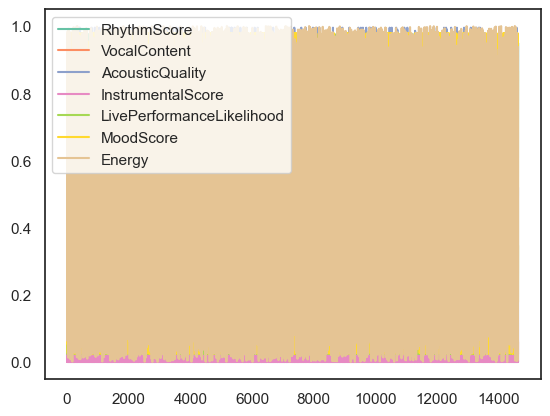

In [21]:
df.drop(columns=['TrackDurationMs', 'BeatsPerMinute', 'AudioLoudness']).plot()

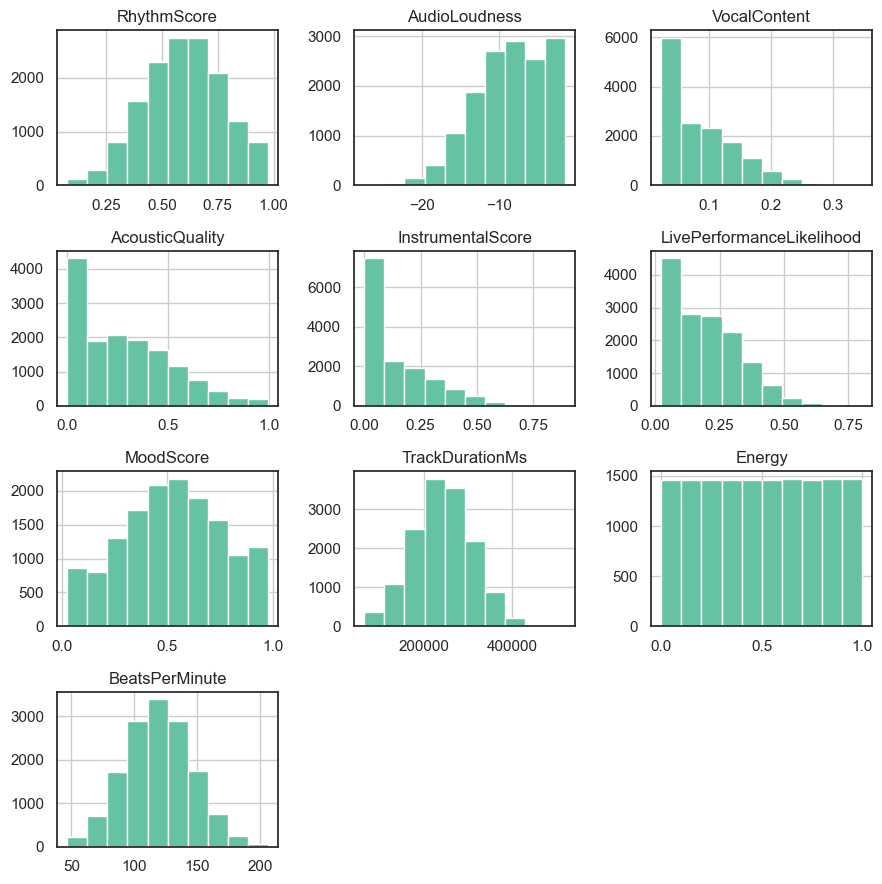

In [22]:
# Plot histograms for all numerical columns to visualize their distributions
df.hist(figsize=(9,9))
plt.tight_layout()
plt.savefig("histogram.jpg")

In [23]:
df_corr = df.drop(columns=['BeatsPerMinute']).corr().abs()

<Axes: >

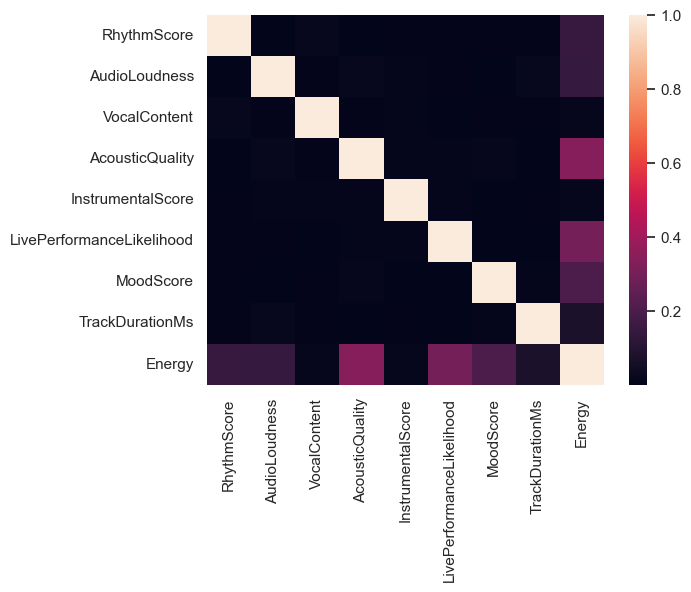

In [24]:
sb.heatmap(df_corr)

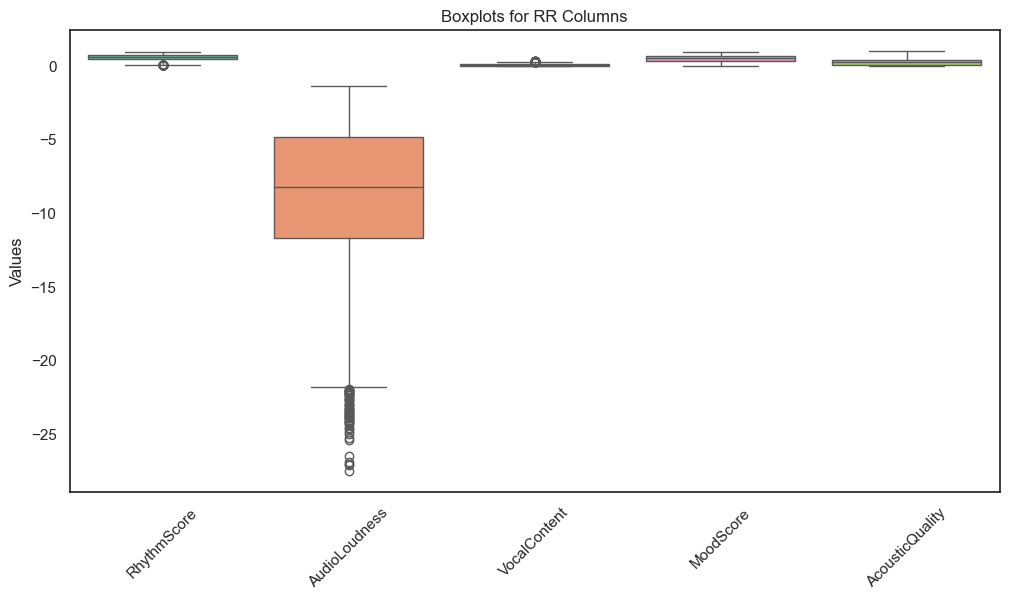

In [25]:
plt.figure(figsize=(12, 6))
columns_to_check = ['RhythmScore', 'AudioLoudness', 'VocalContent', 'MoodScore', 'AcousticQuality']
sb.boxplot(data=df[columns_to_check])
plt.title("Boxplots for RR Columns")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()


In [26]:
columns = df.columns

In [27]:
if isinstance(columns, str):
        columns = [columns]  # make it a list for uniform handling
    
summaries = []
    
for column in columns:
        data = df[column].dropna()
        skewness = data.skew()
        print(f"Column : {column}, Skewness: {skewness:.4f}") 

Column : RhythmScore, Skewness: -0.0977
Column : AudioLoudness, Skewness: -0.3707
Column : VocalContent, Skewness: 0.8246
Column : AcousticQuality, Skewness: 0.6467
Column : InstrumentalScore, Skewness: 1.1782
Column : LivePerformanceLikelihood, Skewness: 0.5723
Column : MoodScore, Skewness: -0.0657
Column : TrackDurationMs, Skewness: 0.0354
Column : Energy, Skewness: -0.0023
Column : BeatsPerMinute, Skewness: 0.0682


C:\Users\AJAY\AppData\Local\Temp\ipykernel_22160\924627065.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


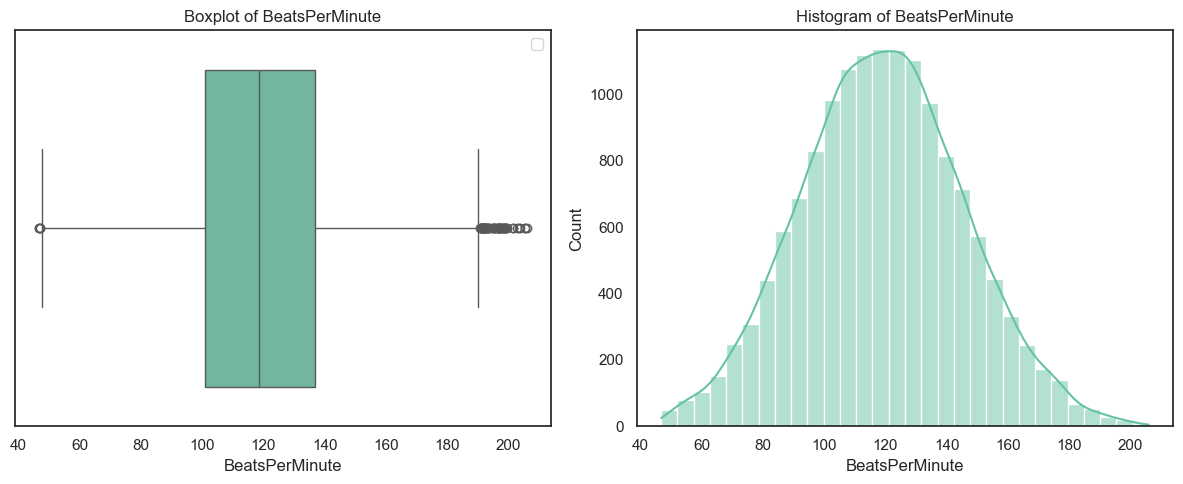

In [28]:
            data = df['BeatsPerMinute']
            plt.figure(figsize=(12,5))
            
            # Boxplot
            plt.subplot(1,2,1)
            sb.boxplot(x=data)
            plt.title(f'Boxplot of {column}')
            plt.legend()
            
            # Histogram
            plt.subplot(1,2,2)
            sb.histplot(data, bins=30, kde=True)

            plt.title(f'Histogram of {column}')
            plt.tight_layout()
            plt.show()

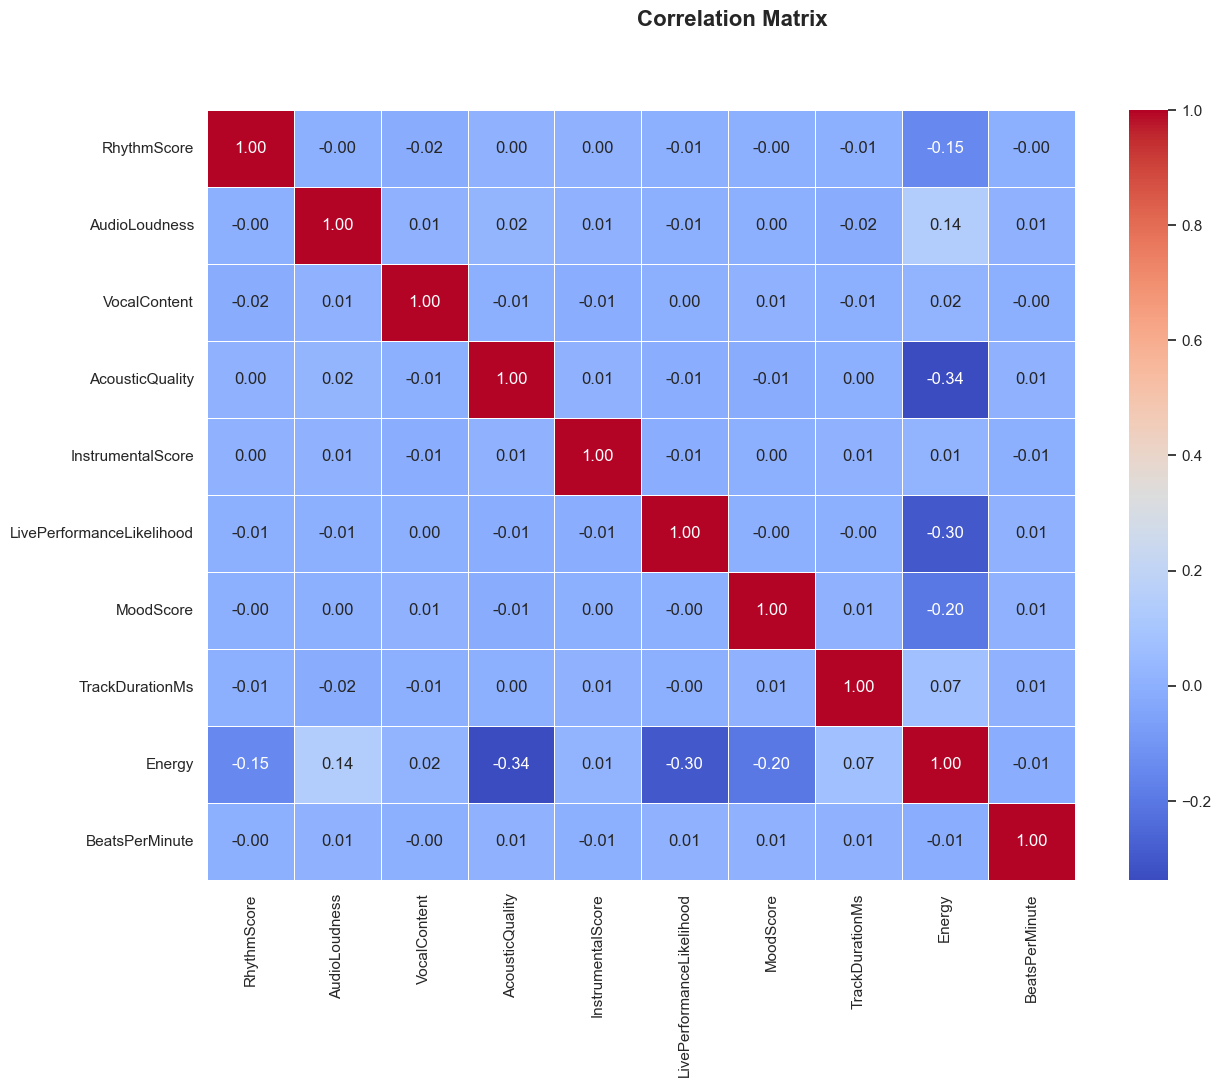

In [29]:
plt.figure(figsize=(14,10))
corr=df.corr()
sb.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.suptitle('Correlation Matrix', fontsize=16, fontweight='bold')
plt.savefig("Correlation_Matrix.jpg")
plt.show()

C:\Users\AJAY\AppData\Local\Temp\ipykernel_22160\3717361401.py:11: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


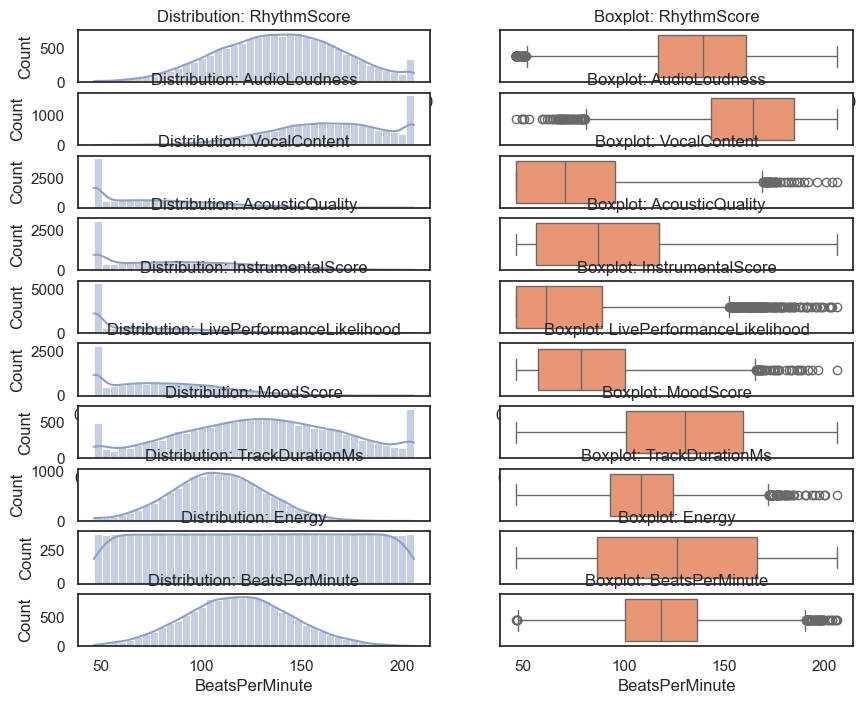

In [30]:
plt.figure(figsize=(10, 8))
for i, col in enumerate(df.columns, 1):
    plt.subplot(len(df.columns), 2, 2*i - 1)
    sb.histplot(df[col], kde=True, bins=40, color="#8da0cb")
    plt.title(f'Distribution: {col}')

    plt.subplot(len(df.columns), 2, 2*i)
    sb.boxplot(x=df[col], color="#fc8d62")
    plt.title(f'Boxplot: {col}')

plt.tight_layout()
plt.savefig("distribution.jpg")
plt.show()

In [31]:
#Check Duplicate Rows
print("Number of Duplicated Row DF : ", df.duplicated().sum())

Number of Duplicated Row DF :  0


##### Skewness

In [32]:
from scipy.stats import skew

skew_values = df[df.columns].apply(lambda x: skew(x.dropna()))
print(skew_values.sort_values(ascending=False))

InstrumentalScore            1.178084
VocalContent                 0.824539
AcousticQuality              0.646649
LivePerformanceLikelihood    0.572277
BeatsPerMinute               0.068187
TrackDurationMs              0.035378
Energy                      -0.002334
MoodScore                   -0.065713
RhythmScore                 -0.097718
AudioLoudness               -0.370624
dtype: float64


In [33]:
skewed_cols = skew_values[abs(skew_values) > 1].index.tolist()
print("Highly skewed columns:", skewed_cols)

for col in skewed_cols:
    df[col] = np.log1p(df[col])
    df[col]  = np.log1p(df[col])

Highly skewed columns: ['InstrumentalScore']


##### Outliers (IQR)

In [34]:


for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    

df

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0.513080,-7.811659,0.071013,0.064564,0.098854,0.316042,0.736929,328639.3188,0.556200,117.092439
1,0.775393,-6.819409,0.023500,0.510599,0.158582,0.024361,0.259488,271967.9826,0.410533,122.002279
2,0.636408,-19.782248,0.063451,0.427861,0.002221,0.024300,0.054848,186147.0029,0.533333,149.130616
3,0.232190,-14.957299,0.023500,0.076268,0.000001,0.228454,0.744650,321734.9723,0.658533,95.832178
4,0.758564,-4.715966,0.023500,0.263551,0.297868,0.197167,0.966592,179973.3982,0.230467,125.696263
...,...,...,...,...,...,...,...,...,...,...
14628,0.769195,-13.608768,0.041826,0.551064,0.113123,0.024300,0.508722,223465.5814,0.473600,82.317428
14629,0.267248,-8.657102,0.023500,0.218652,0.139304,0.287364,0.763650,135276.0877,0.148467,132.107938
14630,0.469302,-1.961814,0.023500,0.912164,0.132769,0.227046,0.619231,134735.8587,0.423133,83.344250
14631,0.588335,-9.766187,0.023500,0.000005,0.047849,0.340709,0.177841,187951.2290,0.340000,121.297185


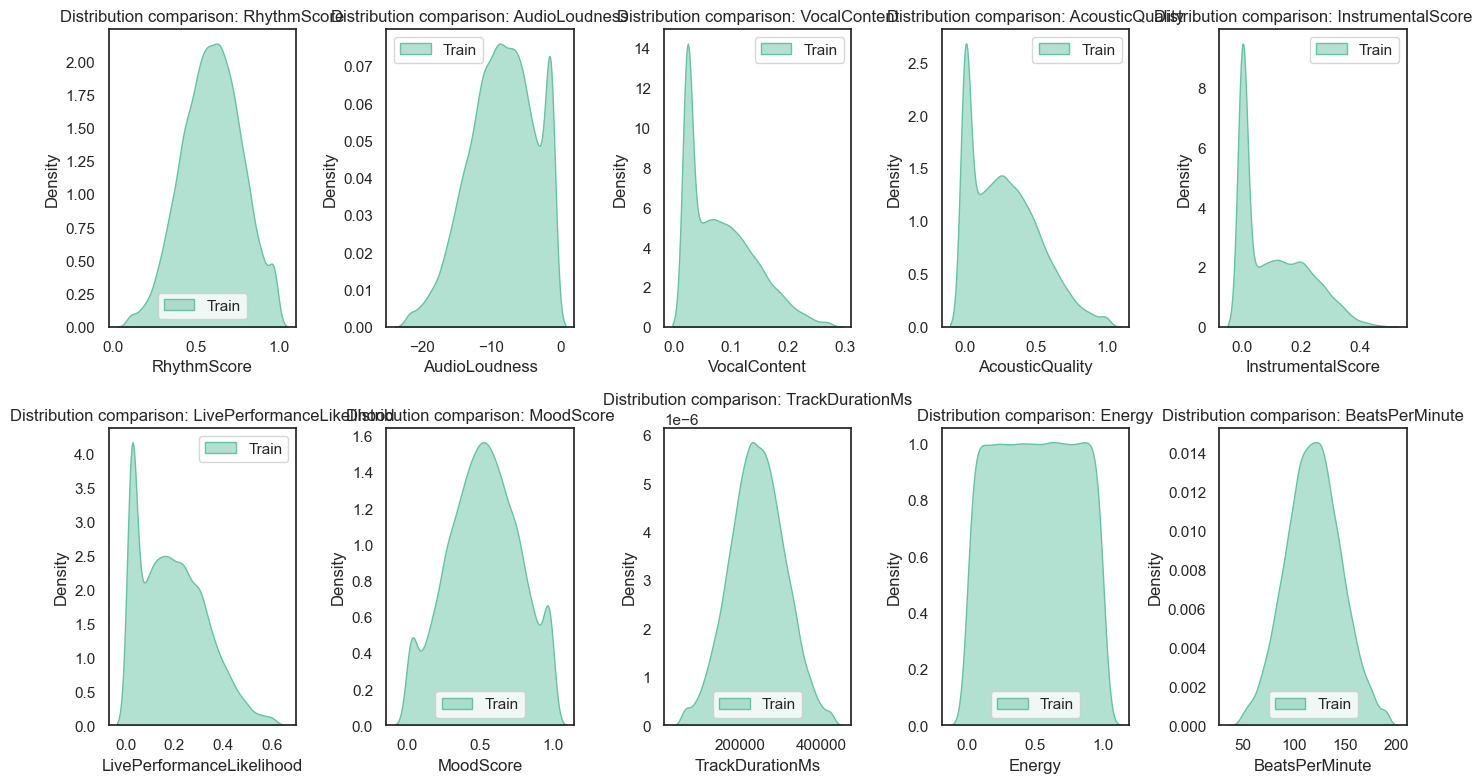

In [35]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(df.columns, 1):
    plt.subplot(2, 5, i)
    sb.kdeplot(df[col], label='Train', fill=True, alpha=0.5)
    plt.title(f'Distribution comparison: {col}')
    plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance

In [38]:
from sklearn.feature_selection import mutual_info_regression

In [39]:
y = df.BeatsPerMinute
X = df.drop(columns=['BeatsPerMinute'])

In [40]:
# Calculate mutual information scores with the target variable
mutual_info = mutual_info_regression(X, y, discrete_features=False, random_state=42)

# Create a DataFrame for better visualization
mutual_info_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual Info Score': mutual_info
}).sort_values(by='Mutual Info Score', ascending=False)

# Display the scores
print(mutual_info_df)

                     Feature  Mutual Info Score
7            TrackDurationMs           0.007607
0                RhythmScore           0.006510
6                  MoodScore           0.000927
5  LivePerformanceLikelihood           0.000448
1              AudioLoudness           0.000000
4          InstrumentalScore           0.000000
3            AcousticQuality           0.000000
2               VocalContent           0.000000
8                     Energy           0.000000


In [42]:
a = X.corrwith(y).to_frame('correlation')
a.sort_values('correlation', ascending=False)

,correlation
LivePerformanceLikelihood,0.010268
TrackDurationMs,0.008868
AudioLoudness,0.006950
AcousticQuality,0.006522
MoodScore,0.005299
RhythmScore,-0.000804
VocalContent,-0.004098
InstrumentalScore,-0.006235
Energy,-0.008513
